# EfficientNet-B3 (Augmented)

**Objective**: This notebook evaluates EfficientNet-B3, which scales depth, width, and resolution together to capture finer dermatological features, applying all lessons from the ResNet experiments from the start.

**Architecture Changes**:
| Component | Previous iteration (ResNet-18 Unfreeze) | This iteration (EfficientNet-B3 Augmented) |
|---|---|---|
| Architecture | ResNet-18 (~11M params) | EfficientNet-B3 (~12M params) |
| Input size | 224×224 | 300×300 |
| Optimizer | Adam | AdamW (decoupled weight decay) |
| Weight decay | 0 | 1e-4 |
| LR scheduler | None | CosineAnnealingLR |
| Augmentation | Basic (h-flip, ±10° rotation) | Strong (v-flip, ±30°, ColorJitter, RandomAffine) |

**Hypothesis**: EfficientNet-B3 should achieve significantly better accuracy per parameter than ResNet-18 due to its native 300×300 input capturing finer features like texture and border irregularity. Applying the best ResNet setup (full fine-tuning, AdamW + CosineAnnealingLR, no dropout, strong augmentation) will maximize this potential.

## Import libraries, set seed, and choose device

In [1]:
import sys
import random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR

ROOT = next(p for p in [Path.cwd()] + list(Path.cwd().parents) if (p / 'src').exists())
sys.path.insert(0, str(ROOT))

from src.data.dataset import HAM10000Dataset
from src.data.dataloader import get_dataloaders
from src.data.transform import get_augmented_train_transforms
from src.models.efficientnet import get_efficientnet
from src.training.trainer import train_one_epoch, validate_one_epoch
from src.utils import plot_training_curves, find_best_threshold, evaluate_model

import pandas as pd

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Using device: {device}')

Using device: cuda


## Load and split data

In [2]:
train_dataset = HAM10000Dataset(
    csv_path=str(ROOT / 'data_new/splits/train.csv'),
    image_dir=str(ROOT / 'data_new/images/train'),
    transform=get_augmented_train_transforms(image_size=300),
)
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4,
    persistent_workers=True,
)

_, val_loader, test_loader = get_dataloaders(
    train_csv=str(ROOT / 'data_new/splits/train.csv'),
    val_csv=str(ROOT / 'data_new/splits/val.csv'),
    test_csv=str(ROOT / 'data_new/splits/test.csv'),
    image_dir=str(ROOT / 'data_new/images/train'),
    test_image_dir=str(ROOT / 'data_new/images/test'),
    batch_size=32,
    image_size=300,
    num_workers=4,
)

train_df     = pd.read_csv(ROOT / 'data_new/splits/train.csv')
num_melanoma = (train_df['label'] == 1).sum()
num_nevus    = (train_df['label'] == 0).sum()
pos_weight   = torch.tensor([num_nevus / num_melanoma], dtype=torch.float32).to(device)
print('Positive weight:', pos_weight)

Positive weight: tensor([8.1117], device='cuda:0')


## Model Definition

In [3]:
model = get_efficientnet(num_classes=1, freeze_backbone=False).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

num_epochs = 20
scheduler  = CosineAnnealingLR(optimizer, T_max=num_epochs)

L1_LAMBDA = 0.0
L2_LAMBDA = 0.0
dropout = 0.0

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Trainable params: {trainable:,} / {total:,}')
print(f'L1 lambda: {L1_LAMBDA} | L2 lambda: {L2_LAMBDA} | Dropout: {dropout}')

Trainable params: 10,697,769 / 10,697,769
L1 lambda: 0.0 | L2 lambda: 0.0 | Dropout: 0.0


## Training Loop

In [4]:
best_val_auc = 0.0
train_history, val_history = [], []

for epoch in range(num_epochs):
    train_metrics = train_one_epoch(
        model, train_loader, criterion, optimizer, device,
        l1_lambda=L1_LAMBDA, l2_lambda=L2_LAMBDA,
    )
    val_metrics = validate_one_epoch(model, val_loader, criterion, device)

    scheduler.step()

    train_history.append(train_metrics)
    val_history.append(val_metrics)

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"  Train | Loss: {train_metrics['loss']:.4f}, Bal Acc: {train_metrics['balanced_accuracy']:.4f}, Recall: {train_metrics['recall']:.4f}, F2: {train_metrics['f2']:.4f}, AUC: {train_metrics['auc']:.4f}")
    print(f"  Val   | Loss: {val_metrics['loss']:.4f}, Bal Acc: {val_metrics['balanced_accuracy']:.4f}, Recall: {val_metrics['recall']:.4f}, F2: {val_metrics['f2']:.4f}, AUC: {val_metrics['auc']:.4f}")

    if val_metrics['auc'] > best_val_auc:
        best_val_auc = val_metrics['auc']
        torch.save(model.state_dict(), str(ROOT / 'models/efficientnet_b3_augment_best.pth'))
        print(f'  -> Saved best model (val AUC: {best_val_auc:.4f})')

Epoch [1/20]
  Train | Loss: 0.9154, Bal Acc: 0.7456, Recall: 0.8278, F2: 0.5476, AUC: 0.8239
  Val   | Loss: 0.8390, Bal Acc: 0.7590, Recall: 0.9576, F2: 0.5777, AUC: 0.8846
  -> Saved best model (val AUC: 0.8846)


Epoch [2/20]
  Train | Loss: 0.7358, Bal Acc: 0.8055, Recall: 0.8609, F2: 0.6249, AUC: 0.8883
  Val   | Loss: 0.7625, Bal Acc: 0.7950, Recall: 0.8814, F2: 0.6216, AUC: 0.8888
  -> Saved best model (val AUC: 0.8888)


Epoch [3/20]
  Train | Loss: 0.6395, Bal Acc: 0.8428, Recall: 0.8826, F2: 0.6810, AUC: 0.9180
  Val   | Loss: 0.7747, Bal Acc: 0.8010, Recall: 0.9449, F2: 0.6264, AUC: 0.9015
  -> Saved best model (val AUC: 0.9015)


Epoch [4/20]
  Train | Loss: 0.5809, Bal Acc: 0.8585, Recall: 0.8905, F2: 0.7070, AUC: 0.9319
  Val   | Loss: 0.7335, Bal Acc: 0.8115, Recall: 0.9407, F2: 0.6401, AUC: 0.9094
  -> Saved best model (val AUC: 0.9094)


Epoch [5/20]
  Train | Loss: 0.5438, Bal Acc: 0.8683, Recall: 0.8997, F2: 0.7229, AUC: 0.9407
  Val   | Loss: 0.7261, Bal Acc: 0.8063, Recall: 0.8856, F2: 0.6368, AUC: 0.9054


...

Epoch [16/20]
  Train | Loss: 0.1933, Bal Acc: 0.9589, Recall: 0.9692, F2: 0.8997, AUC: 0.9924
  Val   | Loss: 1.0179, Bal Acc: 0.8101, Recall: 0.7500, F2: 0.6541, AUC: 0.9061


Epoch [17/20]
  Train | Loss: 0.1887, Bal Acc: 0.9597, Recall: 0.9658, F2: 0.9039, AUC: 0.9929
  Val   | Loss: 1.0078, Bal Acc: 0.8093, Recall: 0.7797, F2: 0.6497, AUC: 0.9034


Epoch [18/20]
  Train | Loss: 0.1859, Bal Acc: 0.9613, Recall: 0.9704, F2: 0.9055, AUC: 0.9929
  Val   | Loss: 1.0904, Bal Acc: 0.8160, Recall: 0.7585, F2: 0.6635, AUC: 0.9040


Epoch [19/20]
  Train | Loss: 0.1810, Bal Acc: 0.9640, Recall: 0.9738, F2: 0.9108, AUC: 0.9932
  Val   | Loss: 1.0378, Bal Acc: 0.8103, Recall: 0.7627, F2: 0.6531, AUC: 0.9060


Epoch [20/20]
  Train | Loss: 0.1809, Bal Acc: 0.9606, Recall: 0.9704, F2: 0.9036, AUC: 0.9933
  Val   | Loss: 1.0341, Bal Acc: 0.8122, Recall: 0.7669, F2: 0.6558, AUC: 0.9056


## Plot Train and Validation Curves

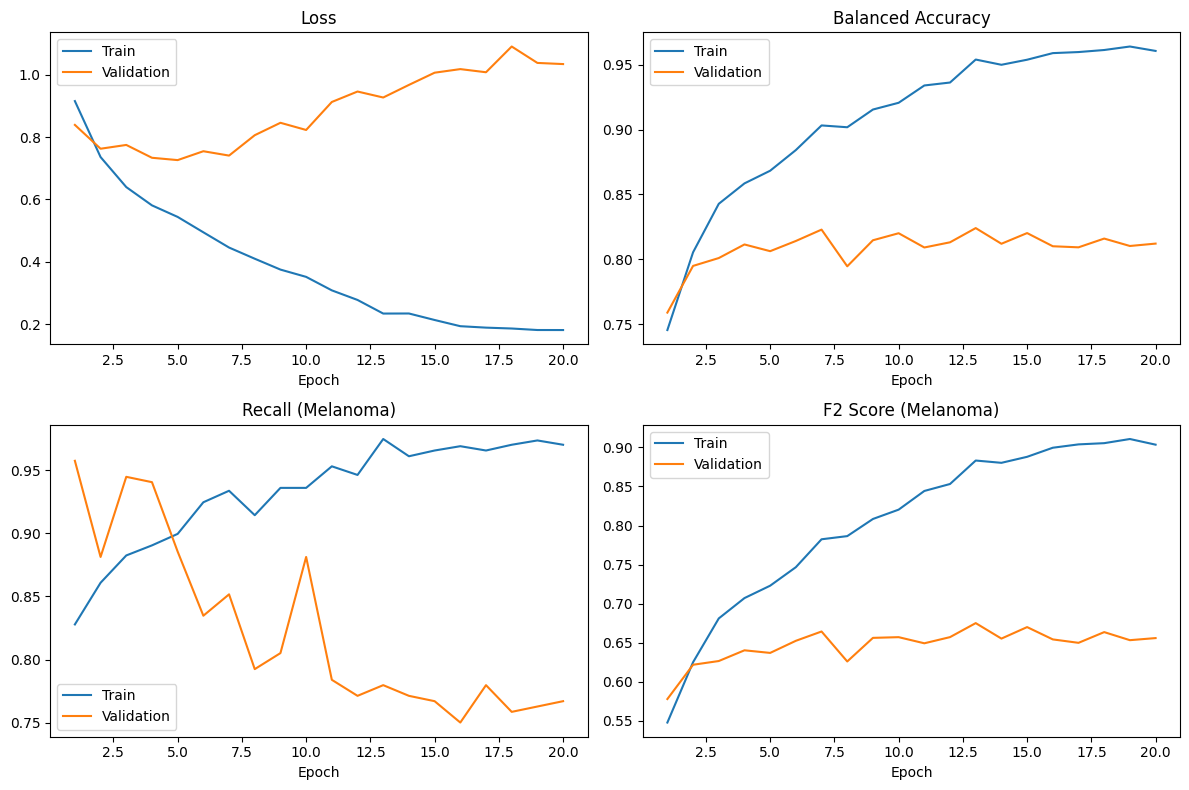

In [5]:
plot_training_curves(train_history, val_history)

## Threshold Tuning (Best Val F2)

In [6]:
model.load_state_dict(torch.load(str(ROOT / 'models/efficientnet_b3_augment_best.pth'), map_location=device))
best_threshold, best_f2 = find_best_threshold(model, val_loader, device)

Best threshold: 0.64 | Val F2: 0.6719


## Test Set Evaluation

Threshold:          0.64
AUC-ROC:            0.9070
Balanced Accuracy:  0.8225
F2 Score:           0.6683

              precision    recall  f1-score   support

Non-Melanoma     0.9683    0.8672    0.9150      1340
    Melanoma     0.4277    0.7778    0.5519       171

    accuracy                         0.8570      1511
   macro avg     0.6980    0.8225    0.7334      1511
weighted avg     0.9071    0.8570    0.8739      1511



c:\Users\Dylan Gay\Documents\SUTD\Deep Learning\50.039-Deep-Learning\dl_venv\Lib\site-packages\sklearn\utils\_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(


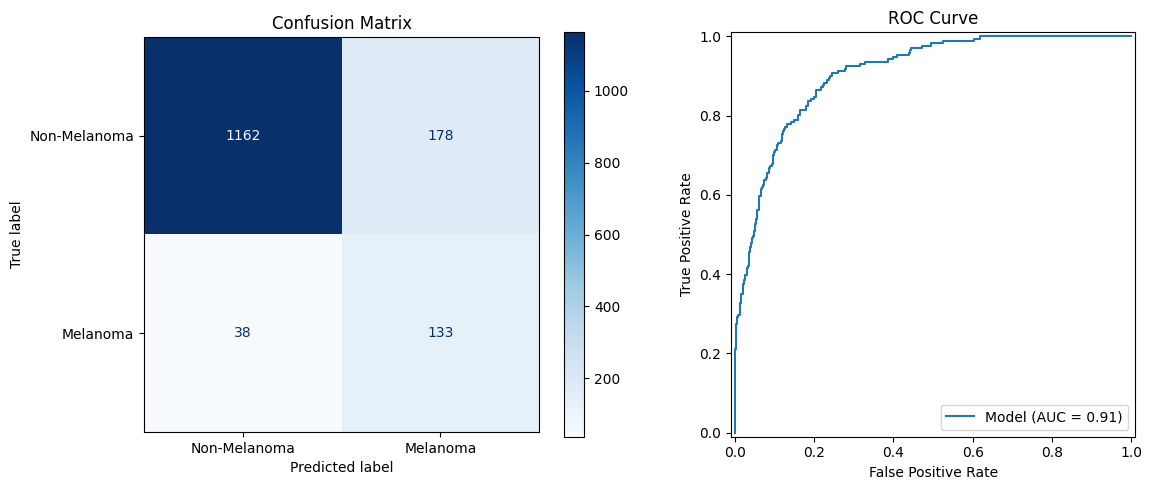

In [7]:
evaluate_model(model, test_loader, device, threshold=best_threshold)